# <center> Module 4-5 Regression: <br>Decision Trees and Random Forests on the GPA Dataset </center>
<center>by: Nicole Woodland, P. Eng. for RoboGarden Inc. </center>

---

In this noteook, we will perform DT & RF's on the GPA dataset. Always start Machine Learning by <b> Asking the Right Question! </b>

<br><center> Can we predict a University grade point average (GPA) for a student based on their High School GPA in a meaningful way? </center>

## Import Libraries

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Read csv file into a dataframe

In [56]:
df = pd.read_csv("../gpa.csv")

In [58]:
df.head(5)

,high_GPA,univ_GPA
0,3.45,3.52
1,2.78,2.91
2,2.52,2.40
3,3.67,3.47
4,3.24,3.47


In [60]:
df.describe()

,high_GPA,univ_GPA
count,105.000000,105.000000
mean,3.076381,3.172857
std,0.516598,0.447194
min,2.030000,2.080000
25%,2.670000,3.010000
50%,3.170000,3.290000
75%,3.480000,3.470000
max,4.000000,3.810000


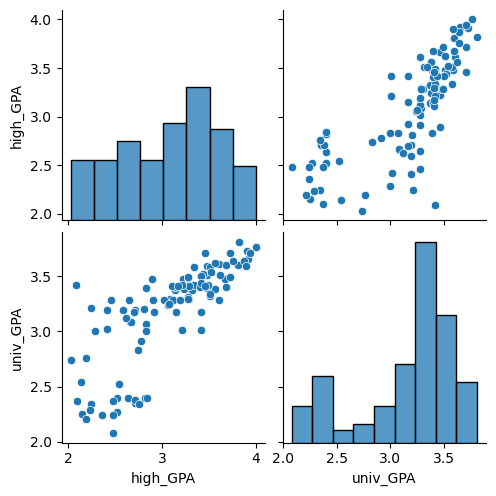

In [62]:
sn.pairplot(df)

## Create Input and Output Data

In [64]:
X = df.iloc[:,0:1].values
y = df.iloc[:,1:2].values

## Create Train and Test Sets

In [68]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2,
                                                    random_state=1)

## Decision Tree Modelling

### Train the Decision Tree Model

In [164]:
from sklearn.tree import DecisionTreeRegressor

modelTree = DecisionTreeRegressor(max_leaf_nodes = 10, max_depth=6).fit(X_train, y_train)
y_pred = modelTree.predict(X_test) 

### Evaluate the DT model

In [167]:
scoreDT = modelTree.score(X_test, y_test)
print(scoreDT)

0.24928628102656225


In [169]:
from sklearn.metrics import mean_squared_error

y_pred = modelTree.predict(X_test)
mean_squared_error(y_test, y_pred)

0.12333494414300115

In [171]:
from sklearn.metrics import mean_absolute_error

y_pred = modelTree.predict(X_test)
mean_absolute_error(y_test, y_pred)

0.26458994708994715

### Visualize the Relationship

*Note this is possible with simple code because only 1 X and 1 y

In [174]:
X_sorted = np.sort(X_train, axis = 0)

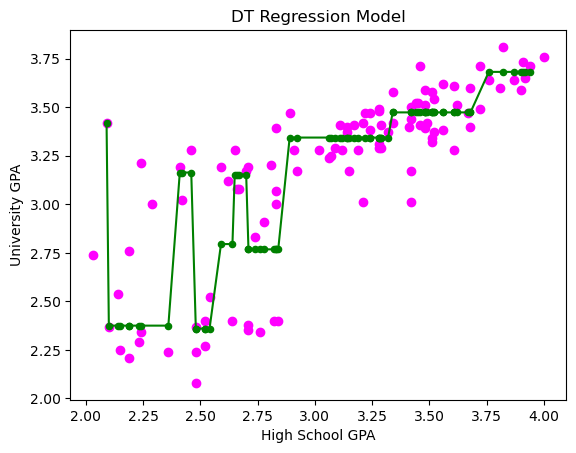

In [176]:
# Plot the provided points
plt.scatter(X, y, color = 'magenta')
predictions = modelTree.predict(X_sorted)

# Draw points based on the predicted values of X_train
plt.plot(X_sorted, predictions, color = 'green', markersize = 20)
plt.scatter(X_sorted, predictions, color = 'green', s = 20)

# Add details
plt.title('DT Regression Model')
plt.xlabel('High School GPA')
plt.ylabel('University GPA')
plt.show()

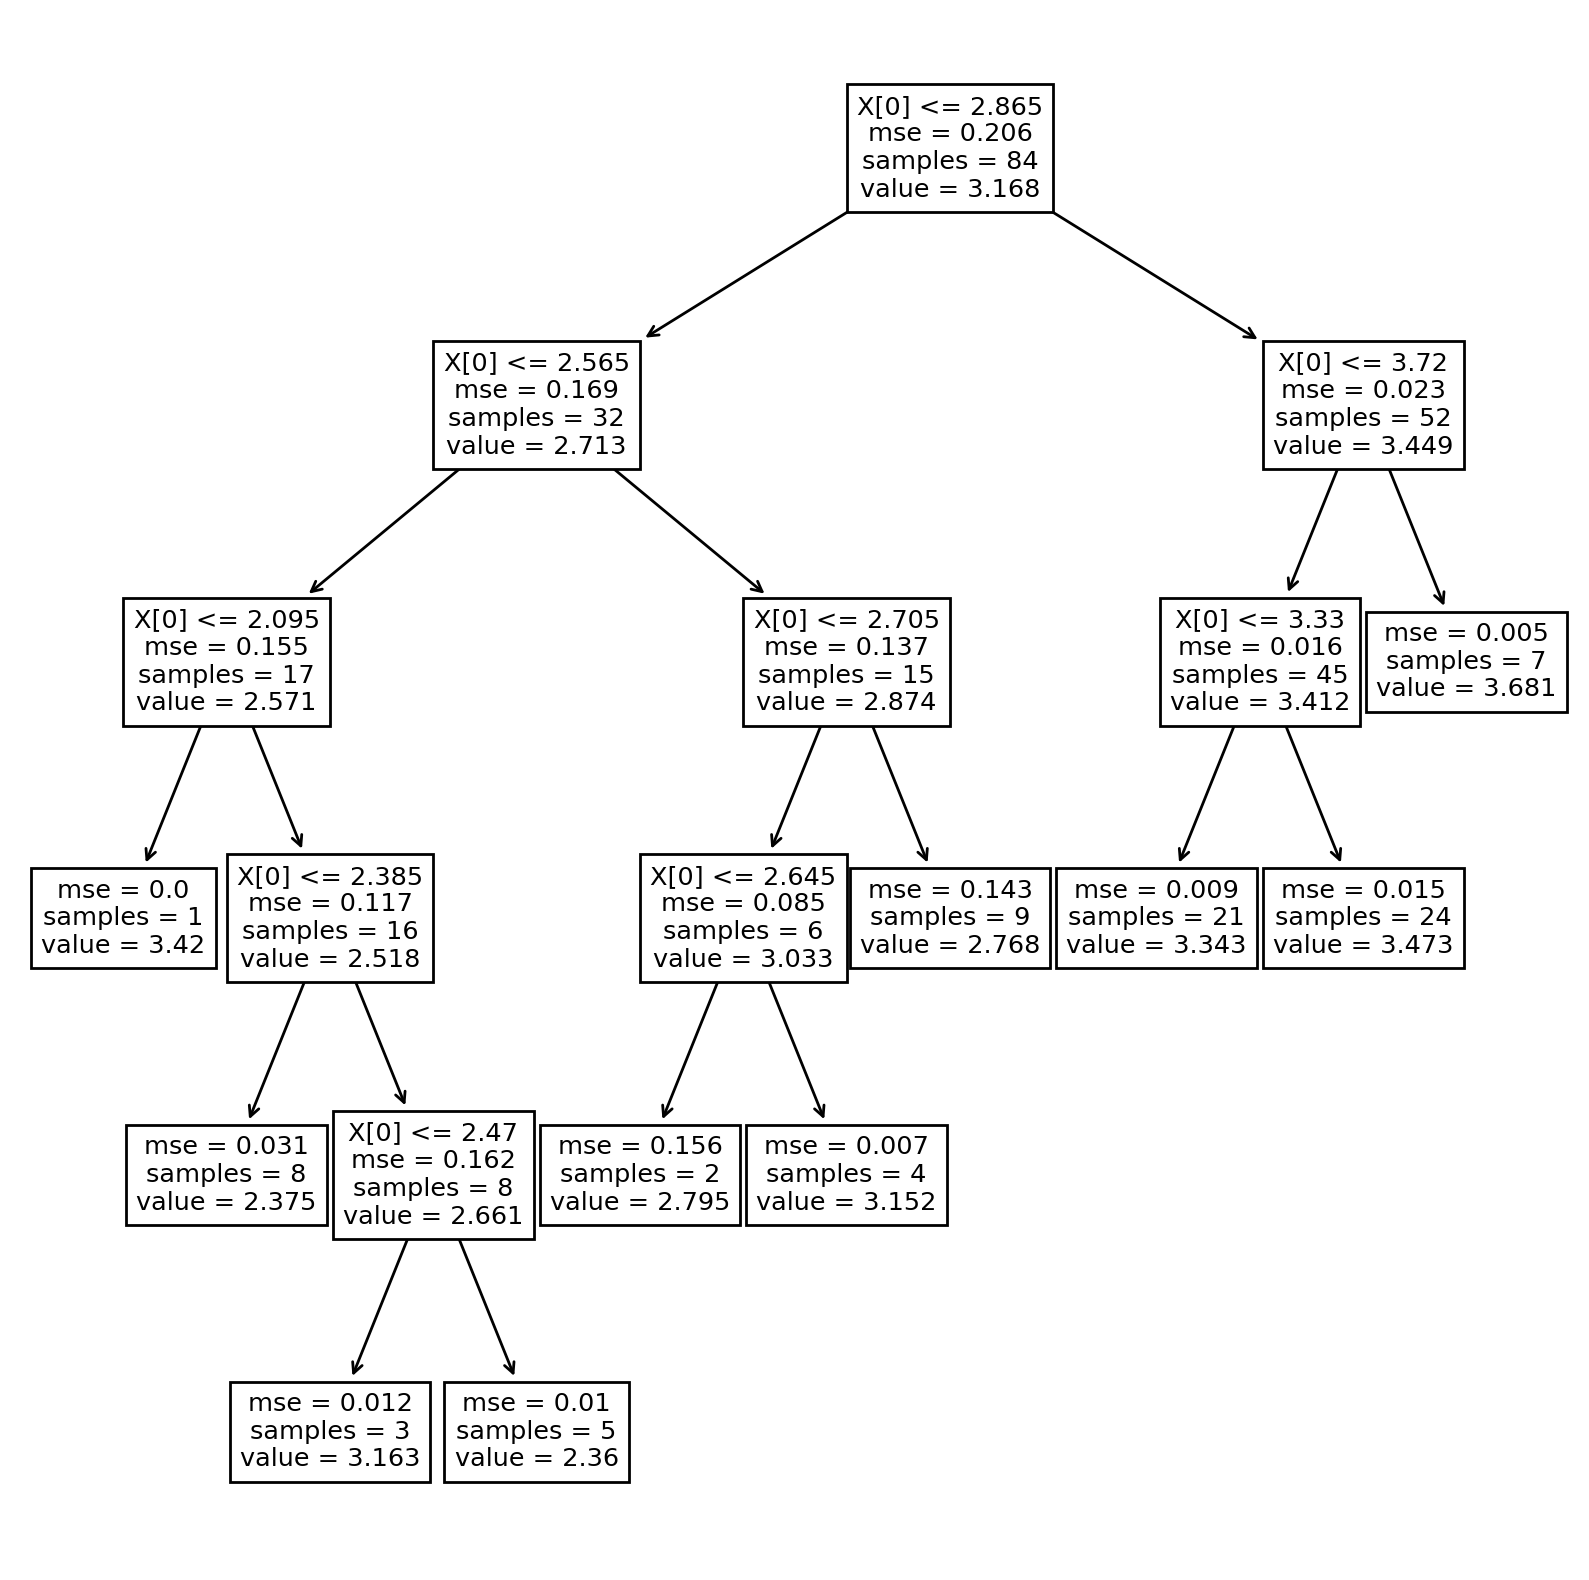

In [178]:
from sklearn.tree import plot_tree
fig, axes = plt.subplots(nrows = 1, ncols = 1, figsize = (10,10), dpi = 200)
plot_tree(modelTree)
plt.savefig("decision_tree.png", format="png", dpi=200, bbox_inches="tight")

## Random Forest Modelling

## Train a Random Forest Model

In [180]:
from sklearn.ensemble import RandomForestRegressor
score=[]
estimator_num=[]
temp_score = []

for estimators in range(1,301,25):
    
    estimator_num.append(estimators)
    modelRandFor = RandomForestRegressor(n_estimators = estimators, 
                                         random_state = 0,
                                        max_leaf_nodes=10).fit(X_train,
                                                               y_train)
    y_predRF = modelRandFor.predict(X_test)
    
    score = (modelRandFor.score(X_test, y_test)).round(3)
    temp_score.append(score)

    print(estimators,'estimators gives a score of:',modelRandFor.score(X_test, y_test))

scoreRF = max(temp_score)
print('Random Forest Maximum Score is:',scoreRF)

1 estimators gives a score of: 0.2775129375748717
26 estimators gives a score of: 0.35055374832950414
51 estimators gives a score of: 0.34088792956115943
76 estimators gives a score of: 0.35533327333723075
101 estimators gives a score of: 0.3568784114250936
126 estimators gives a score of: 0.36989599613252955
151 estimators gives a score of: 0.3676554492568347
176 estimators gives a score of: 0.3517201535212272
201 estimators gives a score of: 0.34903420694181775
226 estimators gives a score of: 0.3551839076518215
251 estimators gives a score of: 0.3548163498391973
276 estimators gives a score of: 0.3485022438060016
Random Forest Maximum Score is: 0.37


In [182]:
from sklearn.metrics import mean_squared_error

y_pred = modelRandFor.predict(X_test)
mean_squared_error(y_test, y_pred)

0.10703472887022125

## Visualize the RF Model

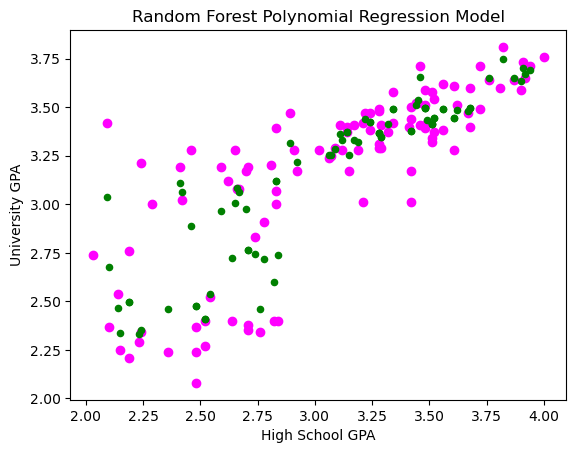

In [184]:
# Retrain a RF model for comparison:
modelRandFor = RandomForestRegressor(n_estimators = 50, 
                                         random_state = 0).fit(X_train,
                                                               y_train)

# Plot the provided points
plt.scatter(X, y, color = 'magenta')
predictions = modelRandFor.predict(X_sorted)

# Draw points based on the predicted values of X_train
plt.scatter(X_sorted, predictions, color = 'green', s = 20)

# Add details
plt.title('Random Forest Polynomial Regression Model')
plt.xlabel('High School GPA')
plt.ylabel('University GPA')
plt.show()

Both the Decision Tree and Random Forest have very poor scores. This indicates DT and RF is not a good model choice for this data. This is likely because with only 1 input, there is not a lot to build the tree on and with the data being relatively linearly correlated, this behaviour is expected.